# Session 1 — processed PPG at 60/120/180 s

Complete multi-window-size experiment for Session 1 using processed data only.

Outputs include per-window peak/PPI QC, per-window frozen Guzzetti metrics, and Awake/Drowsy mean and median summaries at each window size.

**Design caution:** windows at different sizes overlap and may be nested. They are descriptive repeated segments, not independent observations; no p-values are computed.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.signal import find_peaks


def locate_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "phase1" / "src").is_dir():
            return candidate
    raise FileNotFoundError("Cannot locate repository root.")


REPO_ROOT = locate_repo_root(Path.cwd())
SRC_DIR = REPO_ROOT / "phase1" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataloader.loader import load_segmented_session
from symbolic import analyze_symbolic_dynamics

SESSION = "sample_1.csv"
WINDOW_SIZES = (60, 120, 180)
REPRESENTATION = "processed"
STATE_NAMES = {0: "Awake", 1: "Drowsy"}

MIN_PPI_S, MAX_PPI_S = 0.30, 2.00
MIN_PEAK_DISTANCE_S = 0.30
PROMINENCE_FRACTION = 0.20
ABRUPT_THRESHOLDS = (0.20, 0.25, 0.30)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

## 1. Load every segmented processed window

`stationarity_only=False` intentionally retains all exported Session 1 windows. Each row carries `stationarity_pass_processed`, allowing both complete-cohort reporting and stationarity-pass sensitivity summaries.

In [2]:
batches, selected_metadata = load_segmented_session(
    SESSION,
    window_sizes=WINDOW_SIZES,
    representation=REPRESENTATION,
    labels=None,
    stationarity_only=False,
)

windows, cohort_rows = [], []
for window_size_s in WINDOW_SIZES:
    batch = batches[window_size_s]
    order = np.argsort(batch["start_time"])

    for array_index in order:
        label = int(batch["label"][array_index])
        signal = np.asarray(
            batch["signal"][array_index],
            dtype=np.float64,
        )
        window = {
            "key": (
                window_size_s,
                int(batch["window_id"][array_index]),
            ),
            "window_size_s": window_size_s,
            "window_id": int(batch["window_id"][array_index]),
            "state": STATE_NAMES[label],
            "signal": signal,
            "fs": float(batch["fs"]),
            "start_time_s": float(batch["start_time"][array_index]),
            "end_time_s": float(batch["end_time"][array_index]),
            "stationarity_score": float(
                batch["stationarity_score"][array_index]
            ),
            "stationarity_pass": bool(
                batch["stationarity_pass"][array_index]
            ),
        }
        windows.append(window)
        cohort_rows.append({
            "window_size_s": window_size_s,
            "window_id": window["window_id"],
            "State": window["state"],
            "start_time_s": window["start_time_s"],
            "start_time_min": window["start_time_s"] / 60.0,
            "fs_hz": window["fs"],
            "n_samples": signal.size,
            "duration_s": signal.size / window["fs"],
            "stationarity_score_processed": (
                window["stationarity_score"]
            ),
            "stationarity_pass_processed": (
                window["stationarity_pass"]
            ),
        })

cohort_table = (
    pd.DataFrame(cohort_rows)
    .sort_values(["window_size_s", "start_time_s"])
    .reset_index(drop=True)
)
cohort_counts = (
    cohort_table
    .groupby(
        ["window_size_s", "State", "stationarity_pass_processed"],
        observed=True,
    )
    .size()
    .rename("n_windows")
    .reset_index()
)

assert REPRESENTATION == "processed"
assert cohort_table.groupby("window_size_s").size().to_dict() == {
    60: 34, 120: 14, 180: 7,
}
assert len(cohort_table) == 55
assert np.allclose(cohort_table["fs_hz"], 50.0, atol=1e-6)
assert np.allclose(
    cohort_table["duration_s"],
    cohort_table["window_size_s"],
)

display(cohort_counts)
print(f"Total processed windows retained: {len(cohort_table)}")

,window_size_s,State,stationarity_pass_processed,n_windows
0,60,Awake,True,24
1,60,Drowsy,False,3
2,60,Drowsy,True,7
3,120,Awake,True,11
4,120,Drowsy,False,2
5,120,Drowsy,True,1
6,180,Awake,True,6
7,180,Drowsy,True,1


Total processed windows retained: 55


## 2. Peak detection and per-window PPI report

The same detector is used for all 55 windows: no extra smoothing, 0.30-s minimum distance, and prominence = 20% of each signal's P95−P5 robust range. PPI values remain uncorrected.

In [3]:
def detect_ppg_peaks(signal: np.ndarray, fs: float) -> dict:
    robust_range = float(
        np.percentile(signal, 95) - np.percentile(signal, 5)
    )
    if not np.isfinite(robust_range) or robust_range <= 0:
        raise ValueError("Processed PPG must have positive robust range.")

    peaks, properties = find_peaks(
        signal,
        distance=int(np.ceil(MIN_PEAK_DISTANCE_S * fs)),
        prominence=PROMINENCE_FRACTION * robust_range,
    )
    if peaks.size < 4:
        raise RuntimeError("Too few peaks for PPI/symbolic analysis.")

    peak_times_s = peaks.astype(float) / fs
    ppi_s = np.diff(peak_times_s)
    invalid = (ppi_s < MIN_PPI_S) | (ppi_s > MAX_PPI_S)
    return {
        "peaks": peaks,
        "peak_times_s": peak_times_s,
        "prominences": properties["prominences"],
        "prominence_threshold": PROMINENCE_FRACTION * robust_range,
        "ppi_s": ppi_s,
        "hr_bpm": 60.0 / ppi_s,
        "invalid": invalid,
        "relative_change": np.abs(np.diff(ppi_s)) / ppi_s[:-1],
    }


peak_results, per_window_qc_rows, abrupt_event_rows = {}, [], []

for window in windows:
    result = detect_ppg_peaks(window["signal"], window["fs"])
    peak_results[window["key"]] = result
    ppi_s = result["ppi_s"]
    relative_change = result["relative_change"]
    n_invalid = int(result["invalid"].sum())

    row = {
        "window_size_s": window["window_size_s"],
        "window_id": window["window_id"],
        "State": window["state"],
        "start_time_min": window["start_time_s"] / 60.0,
        "stationarity_pass_processed": window["stationarity_pass"],
        "stationarity_score_processed": window["stationarity_score"],
        "prominence": result["prominence_threshold"],
        "n_peaks": result["peaks"].size,
        "n_ppi": ppi_s.size,
        "mean_hr_bpm": np.mean(result["hr_bpm"]),
        "median_hr_bpm": np.median(result["hr_bpm"]),
        "mean_ppi_ms": 1000 * np.mean(ppi_s),
        "median_ppi_ms": 1000 * np.median(ppi_s),
        "sd_ppi_ms": 1000 * np.std(ppi_s, ddof=1),
        "cv_ppi": np.std(ppi_s, ddof=1) / np.mean(ppi_s),
        "min_ppi_ms": 1000 * np.min(ppi_s),
        "max_ppi_ms": 1000 * np.max(ppi_s),
        "n_invalid_ppi": n_invalid,
        "invalid_pct": 100 * n_invalid / ppi_s.size,
    }
    for threshold in ABRUPT_THRESHOLDS:
        label = int(100 * threshold)
        count = int(np.sum(relative_change > threshold))
        row[f"n_abrupt_gt_{label}pct"] = count
        row[f"abrupt_gt_{label}pct"] = (
            100 * count / relative_change.size
        )
    per_window_qc_rows.append(row)

    for index in np.flatnonzero(relative_change > 0.20):
        abrupt_event_rows.append({
            "window_size_s": window["window_size_s"],
            "window_id": window["window_id"],
            "State": window["state"],
            "stationarity_pass_processed": window["stationarity_pass"],
            "transition_time_s": result["peak_times_s"][index + 1],
            "previous_ppi_ms": 1000 * ppi_s[index],
            "current_ppi_ms": 1000 * ppi_s[index + 1],
            "relative_change_pct": 100 * relative_change[index],
        })

per_window_qc_table = (
    pd.DataFrame(per_window_qc_rows)
    .sort_values(["window_size_s", "start_time_min"])
    .reset_index(drop=True)
)
abrupt_events_table = pd.DataFrame(abrupt_event_rows)

assert np.all(
    per_window_qc_table["n_ppi"]
    == per_window_qc_table["n_peaks"] - 1
)
display(per_window_qc_table)
print(
    "Total invalid PPI:",
    int(per_window_qc_table["n_invalid_ppi"].sum()),
)
display(abrupt_events_table)

,window_size_s,window_id,State,start_time_min,stationarity_pass_processed,stationarity_score_processed,prominence,n_peaks,n_ppi,mean_hr_bpm,median_hr_bpm,mean_ppi_ms,median_ppi_ms,sd_ppi_ms,cv_ppi,min_ppi_ms,max_ppi_ms,n_invalid_ppi,invalid_pct,n_abrupt_gt_20pct,abrupt_gt_20pct,n_abrupt_gt_25pct,abrupt_gt_25pct,n_abrupt_gt_30pct,abrupt_gt_30pct
0,60,1,Awake,0.044,True,0.093,120.176,80,79,80.181,81.081,750.633,740.000,42.346,0.056,660.000,880.000,0,0.000,0,0.000,0,0.000,0,0.000
1,60,2,Awake,1.044,True,0.105,112.334,80,79,80.161,78.947,751.392,760.000,46.815,0.062,640.000,860.000,0,0.000,0,0.000,0,0.000,0,0.000
2,60,3,Awake,2.044,True,0.134,110.836,85,84,85.689,85.714,704.048,700.000,52.483,0.075,600.000,820.000,0,0.000,0,0.000,0,0.000,0,0.000
3,60,4,Awake,3.044,True,0.098,110.348,81,80,81.086,81.081,742.250,740.000,42.812,0.058,660.000,900.000,0,0.000,0,0.000,0,0.000,0,0.000
4,60,5,Awake,4.044,True,0.124,106.971,82,81,82.578,81.081,728.642,740.000,38.851,0.053,640.000,820.000,0,0.000,0,0.000,0,0.000,0,0.000
5,60,6,Awake,5.044,True,0.390,115.841,76,75,77.946,76.923,778.667,780.000,84.619,0.109,620.000,980.000,0,0.000,0,0.000,0,0.000,0,0.000
6,60,7,Awake,6.044,True,0.179,99.597,80,79,80.461,81.081,748.101,740.000,42.790,0.057,640.000,880.000,0,0.000,2,2.564,0,0.000,0,0.000
7,60,8,Awake,7.044,True,0.493,97.153,92,91,92.369,90.909,653.626,660.000,51.887,0.079,560.000,760.000,0,0.000,2,2.222,2,2.222,0,0.000
8,60,9,Awake,8.044,True,0.156,97.765,84,83,84.564,83.333,714.458,720.000,58.544,0.082,580.000,840.000,0,0.000,0,0.000,0,0.000,0,0.000
9,60,10,Awake,9.044,True,0.106,98.567,79,78,79.957,78.947,753.590,760.000,49.882,0.066,640.000,920.000,0,0.000,1,1.299,0,0.000,0,0.000


Total invalid PPI: 0


,window_size_s,window_id,State,stationarity_pass_processed,transition_time_s,previous_ppi_ms,current_ppi_ms,relative_change_pct
0,60,7,Awake,True,29.720,720.000,880.000,22.222
1,60,7,Awake,True,30.600,880.000,700.000,20.455
2,60,8,Awake,True,5.980,600.000,760.000,26.667
3,60,8,Awake,True,33.340,760.000,560.000,26.316
4,60,10,Awake,True,18.740,680.000,820.000,20.588
...,...,...,...,...,...,...,...,...
110,180,4,Awake,True,18.740,680.000,820.000,20.588
111,180,6,Drowsy,True,11.980,640.000,800.000,25.000
112,180,6,Drowsy,True,18.340,680.000,860.000,26.471
113,180,6,Drowsy,True,19.200,860.000,440.000,48.837


### Awake/Drowsy mean and median PPI summaries

The complete-cohort table uses all 55 processed windows. The second table repeats the summary after retaining only processed-stationarity-pass windows.

In [4]:
def grouped_mean_median(
    frame: pd.DataFrame,
    metrics: list[str],
) -> pd.DataFrame:
    grouped = frame.groupby(
        ["window_size_s", "State"],
        observed=True,
        sort=True,
    )
    result = grouped.size().rename("n_windows").to_frame()
    for metric in metrics:
        result[f"{metric}_mean"] = grouped[metric].mean()
        result[f"{metric}_median"] = grouped[metric].median()
    return result.reset_index()


ppi_summary_metrics = [
    "n_ppi",
    "mean_hr_bpm",
    "median_hr_bpm",
    "mean_ppi_ms",
    "median_ppi_ms",
    "sd_ppi_ms",
    "cv_ppi",
    "invalid_pct",
]
ppi_group_summary_all = grouped_mean_median(
    per_window_qc_table,
    ppi_summary_metrics,
)
ppi_group_summary_stationary = grouped_mean_median(
    per_window_qc_table.query("stationarity_pass_processed"),
    ppi_summary_metrics,
)

print("All processed windows")
display(ppi_group_summary_all)
print("Processed-stationarity-pass sensitivity cohort")
display(ppi_group_summary_stationary)

All processed windows


,window_size_s,State,n_windows,n_ppi_mean,n_ppi_median,mean_hr_bpm_mean,mean_hr_bpm_median,median_hr_bpm_mean,median_hr_bpm_median,mean_ppi_ms_mean,mean_ppi_ms_median,median_ppi_ms_mean,median_ppi_ms_median,sd_ppi_ms_mean,sd_ppi_ms_median,cv_ppi_mean,cv_ppi_median,invalid_pct_mean,invalid_pct_median
0,60,Awake,24,79.792,79.000,81.513,81.020,81.320,81.081,740.698,745.823,738.750,740.000,50.552,50.274,0.068,0.066,0.000,0.000
1,60,Drowsy,10,81.300,82.000,83.646,83.869,82.770,83.333,723.776,720.732,725.000,720.000,62.349,58.818,0.086,0.082,0.000,0.000
2,120,Awake,11,161.091,159.000,81.731,80.650,81.341,81.081,738.885,750.506,738.182,740.000,55.410,57.663,0.075,0.079,0.000,0.000
3,120,Drowsy,3,164.333,164.000,83.860,83.979,82.583,83.333,723.437,725.244,726.667,720.000,69.510,57.593,0.096,0.079,0.000,0.000
4,180,Awake,6,242.500,241.500,81.734,81.295,81.142,81.081,738.877,741.977,740.000,740.000,56.216,57.373,0.076,0.076,0.000,0.000
5,180,Drowsy,1,247.000,247.000,83.379,83.379,83.333,83.333,723.644,723.644,720.000,720.000,52.557,52.557,0.073,0.073,0.000,0.000


Processed-stationarity-pass sensitivity cohort


,window_size_s,State,n_windows,n_ppi_mean,n_ppi_median,mean_hr_bpm_mean,mean_hr_bpm_median,median_hr_bpm_mean,median_hr_bpm_median,mean_ppi_ms_mean,mean_ppi_ms_median,median_ppi_ms_mean,median_ppi_ms_median,sd_ppi_ms_mean,sd_ppi_ms_median,cv_ppi_mean,cv_ppi_median,invalid_pct_mean,invalid_pct_median
0,60,Awake,24,79.792,79.000,81.513,81.020,81.320,81.081,740.698,745.823,738.750,740.000,50.552,50.274,0.068,0.066,0.000,0.000
1,60,Drowsy,7,81.000,81.000,83.357,83.774,82.529,83.333,725.882,723.457,727.143,720.000,60.382,61.427,0.083,0.086,0.000,0.000
2,120,Awake,11,161.091,159.000,81.731,80.650,81.341,81.081,738.885,750.506,738.182,740.000,55.410,57.663,0.075,0.079,0.000,0.000
3,120,Drowsy,1,163.000,163.000,83.081,83.081,83.333,83.333,727.117,727.117,720.000,720.000,57.593,57.593,0.079,0.079,0.000,0.000
4,180,Awake,6,242.500,241.500,81.734,81.295,81.142,81.081,738.877,741.977,740.000,740.000,56.216,57.373,0.076,0.076,0.000,0.000
5,180,Drowsy,1,247.000,247.000,83.379,83.379,83.333,83.333,723.644,723.644,720.000,720.000,52.557,52.557,0.073,0.073,0.000,0.000


## 3. Representative visual peak audit

Plotting all 55 waveforms would obscure morphology. The audit therefore uses the first stationarity-pass Awake and Drowsy window at each duration, while numerical QC above still covers every window.

Each row contains the full waveform and the prescribed 0–10 s, 85–95 s and final-10-s zoom.

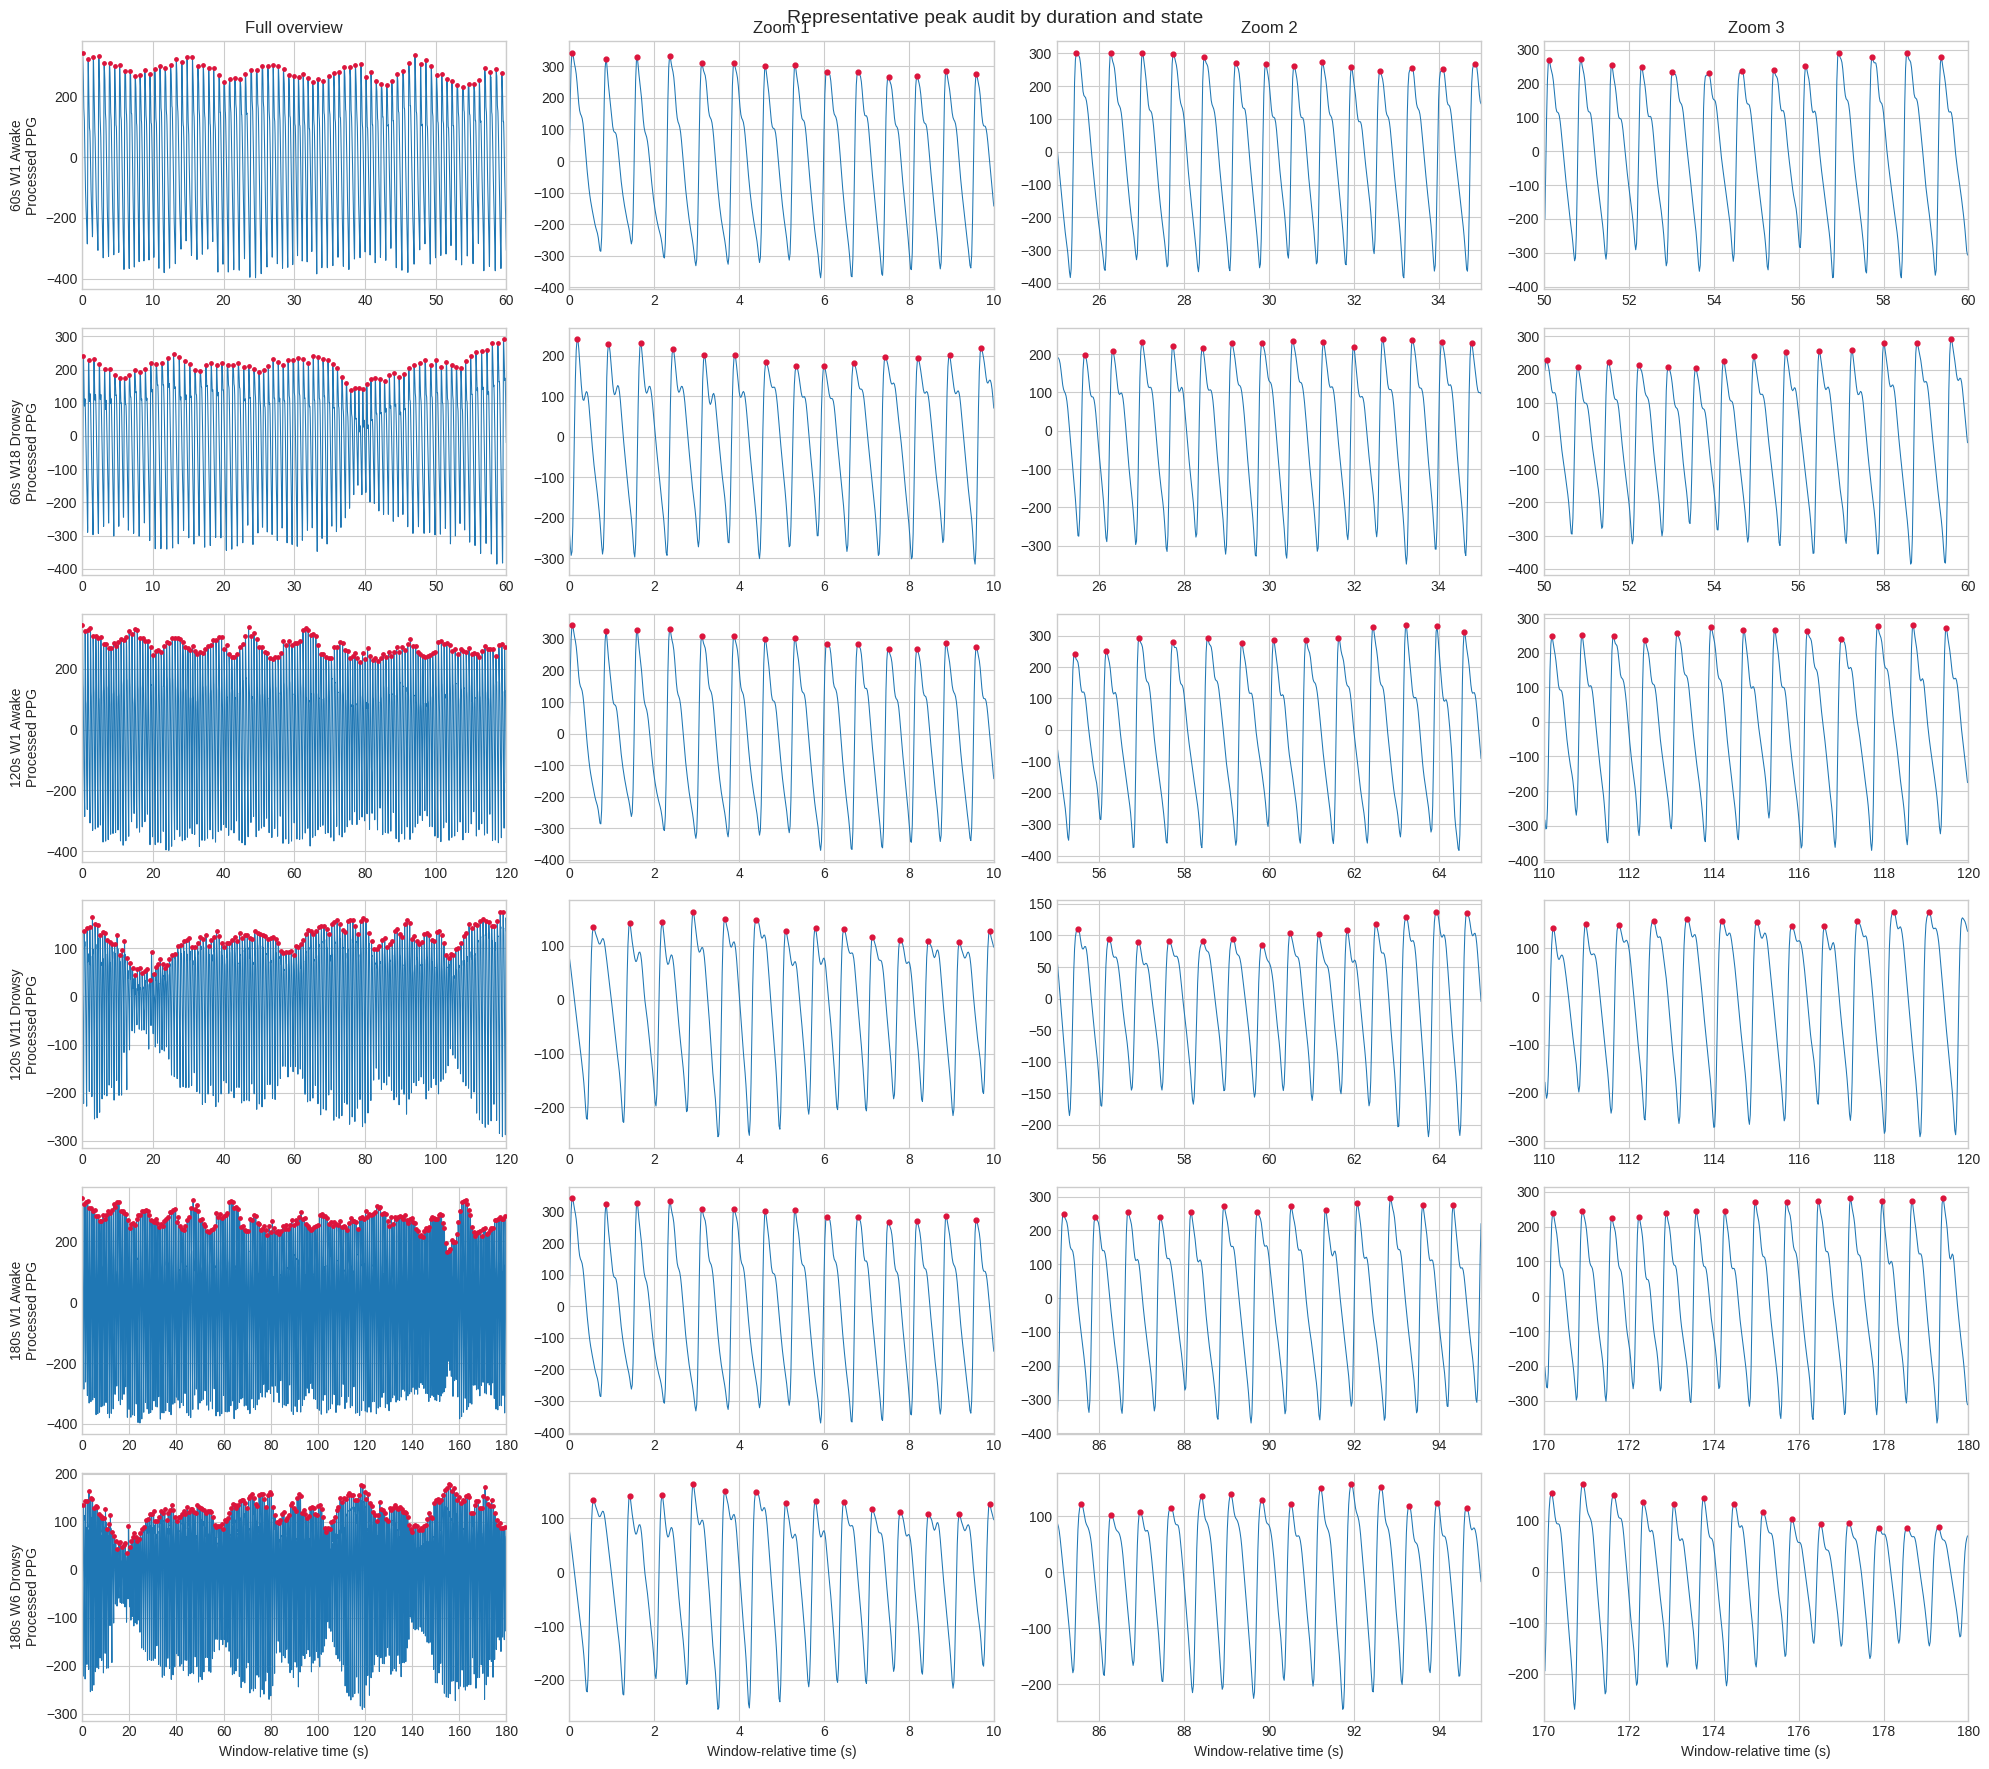

In [5]:
representatives = []
for window_size_s in WINDOW_SIZES:
    for state in ("Awake", "Drowsy"):
        candidates = [
            window for window in windows
            if window["window_size_s"] == window_size_s
            and window["state"] == state
            and window["stationarity_pass"]
        ]
        if candidates:
            representatives.append(
                min(candidates, key=lambda item: item["start_time_s"])
            )

fig, axes = plt.subplots(
    len(representatives),
    4,
    figsize=(20, 3.0 * len(representatives)),
    squeeze=False,
)

for row, window in enumerate(representatives):
    result = peak_results[window["key"]]
    signal = window["signal"]
    time_s = np.arange(signal.size) / window["fs"]
    peak_times_s = result["peak_times_s"]
    zooms = [
        (0, window["window_size_s"]),
        (0, min(10, window["window_size_s"])),
        (
            max(0, window["window_size_s"] / 2 - 5),
            min(window["window_size_s"], window["window_size_s"] / 2 + 5),
        ),
        (
            max(0, window["window_size_s"] - 10),
            window["window_size_s"],
        ),
    ]

    for column, (start_s, end_s) in enumerate(zooms):
        axis = axes[row, column]
        sample_mask = (time_s >= start_s) & (time_s <= end_s)
        peak_mask = (
            (peak_times_s >= start_s) & (peak_times_s <= end_s)
        )
        axis.plot(time_s[sample_mask], signal[sample_mask], linewidth=0.75)
        axis.scatter(
            peak_times_s[peak_mask],
            signal[result["peaks"][peak_mask]],
            color="crimson",
            s=12 if column else 6,
            zorder=3,
        )
        axis.set_xlim(start_s, end_s)
        if row == 0:
            axis.set_title(
                ("Full overview" if column == 0 else f"Zoom {column}")
            )
        if column == 0:
            axis.set_ylabel(
                f"{window['window_size_s']}s W{window['window_id']} "
                f"{window['state']}\nProcessed PPG"
            )
        if row == len(representatives) - 1:
            axis.set_xlabel("Window-relative time (s)")

fig.suptitle(
    "Representative peak audit by duration and state",
    fontsize=14,
)
fig.tight_layout()
plt.show()

## 4. Frozen symbolic dynamics — individual-window report

All uncorrected PPI sequences are passed directly to the frozen core. Invariants are asserted independently for every one of the 55 windows.

In [6]:
symbolic_results, per_window_symbolic_rows = {}, []

for window in windows:
    peak_result = peak_results[window["key"]]
    if np.any(peak_result["invalid"]):
        raise RuntimeError(
            f"Invalid PPI in {window['window_size_s']}s "
            f"window {window['window_id']}."
        )

    result = analyze_symbolic_dynamics(peak_result["ppi_s"])
    symbolic_results[window["key"]] = result
    family_total = (
        result.pct_0v + result.pct_1v
        + result.pct_2lv + result.pct_2uv
    )
    metrics = np.array([
        result.pct_0v, result.pct_1v,
        result.pct_2lv, result.pct_2uv, result.pct_2v,
    ])
    assert np.isfinite(metrics).all()
    assert np.isclose(family_total, 100.0)
    assert np.isclose(result.pct_2v, result.pct_2lv + result.pct_2uv)
    assert result.n_words == result.n_intervals - 2

    per_window_symbolic_rows.append({
        "window_size_s": window["window_size_s"],
        "window_id": window["window_id"],
        "State": window["state"],
        "start_time_min": window["start_time_s"] / 60.0,
        "stationarity_pass_processed": window["stationarity_pass"],
        "n_intervals": result.n_intervals,
        "n_words": result.n_words,
        "0V_pct": result.pct_0v,
        "1V_pct": result.pct_1v,
        "2LV_pct": result.pct_2lv,
        "2UV_pct": result.pct_2uv,
        "2V_pct": result.pct_2v,
        "family_total_pct": family_total,
        "invariants_pass": True,
    })

per_window_symbolic_table = (
    pd.DataFrame(per_window_symbolic_rows)
    .sort_values(["window_size_s", "start_time_min"])
    .reset_index(drop=True)
)
display(per_window_symbolic_table)

,window_size_s,window_id,State,start_time_min,stationarity_pass_processed,n_intervals,n_words,0V_pct,1V_pct,2LV_pct,2UV_pct,2V_pct,family_total_pct,invariants_pass
0,60,1,Awake,0.044,True,79,77,16.883,46.753,15.584,20.779,36.364,100.000,True
1,60,2,Awake,1.044,True,79,77,12.987,40.260,20.779,25.974,46.753,100.000,True
2,60,3,Awake,2.044,True,84,82,29.268,41.463,7.317,21.951,29.268,100.000,True
3,60,4,Awake,3.044,True,80,78,20.513,43.590,14.103,21.795,35.897,100.000,True
4,60,5,Awake,4.044,True,81,79,8.861,53.165,15.190,22.785,37.975,100.000,True
5,60,6,Awake,5.044,True,75,73,19.178,53.425,12.329,15.068,27.397,100.000,True
6,60,7,Awake,6.044,True,79,77,15.584,41.558,5.195,37.662,42.857,100.000,True
7,60,8,Awake,7.044,True,91,89,24.719,35.955,5.618,33.708,39.326,100.000,True
8,60,9,Awake,8.044,True,83,81,29.630,49.383,8.642,12.346,20.988,100.000,True
9,60,10,Awake,9.044,True,78,76,11.842,53.947,7.895,26.316,34.211,100.000,True


## 5. Awake/Drowsy symbolic mean and median at each duration

The first table is the requested complete processed-window summary. The second is the processed-stationarity-pass sensitivity summary. `n_windows` must be read alongside every mean/median—especially Drowsy at 120 and 180 s.

In [7]:
symbolic_metrics = [
    "0V_pct", "1V_pct", "2LV_pct", "2UV_pct", "2V_pct",
]
symbolic_group_summary_all = grouped_mean_median(
    per_window_symbolic_table,
    symbolic_metrics,
)
symbolic_group_summary_stationary = grouped_mean_median(
    per_window_symbolic_table.query("stationarity_pass_processed"),
    symbolic_metrics,
)

print("All processed windows")
display(symbolic_group_summary_all)
print("Processed-stationarity-pass sensitivity cohort")
display(symbolic_group_summary_stationary)

All processed windows


,window_size_s,State,n_windows,0V_pct_mean,0V_pct_median,1V_pct_mean,1V_pct_median,2LV_pct_mean,2LV_pct_median,2UV_pct_mean,2UV_pct_median,2V_pct_mean,2V_pct_median
0,60,Awake,24,20.972,18.563,46.017,46.104,10.429,8.808,22.582,22.577,33.011,35.632
1,60,Drowsy,10,24.940,24.696,43.462,44.658,7.187,6.875,24.411,20.881,31.598,29.119
2,120,Awake,11,32.155,34.615,43.967,42.949,6.382,5.625,17.495,16.770,23.878,22.436
3,120,Drowsy,3,37.399,35.802,37.552,36.646,3.276,3.086,21.774,18.634,25.050,23.171
4,180,Awake,6,28.526,25.207,48.367,49.274,5.852,5.846,17.255,18.369,23.106,24.632
5,180,Drowsy,1,40.408,40.408,40.000,40.000,1.633,1.633,17.959,17.959,19.592,19.592


Processed-stationarity-pass sensitivity cohort


,window_size_s,State,n_windows,0V_pct_mean,0V_pct_median,1V_pct_mean,1V_pct_median,2LV_pct_mean,2LV_pct_median,2UV_pct_mean,2UV_pct_median,2V_pct_mean,2V_pct_median
0,60,Awake,24,20.972,18.563,46.017,46.104,10.429,8.808,22.582,22.577,33.011,35.632
1,60,Drowsy,7,24.200,25.641,42.446,44.872,8.482,8.974,24.873,20.513,33.354,29.487
2,120,Awake,11,32.155,34.615,43.967,42.949,6.382,5.625,17.495,16.770,23.878,22.436
3,120,Drowsy,1,42.857,42.857,36.646,36.646,1.863,1.863,18.634,18.634,20.497,20.497
4,180,Awake,6,28.526,25.207,48.367,49.274,5.852,5.846,17.255,18.369,23.106,24.632
5,180,Drowsy,1,40.408,40.408,40.000,40.000,1.633,1.633,17.959,17.959,19.592,19.592


## 6. Duration-wise pattern

Faint points are individual windows. Solid markers/lines are group means and dashed markers/lines are medians. These are overlapping/nested windows and should not be interpreted as independent replicates.

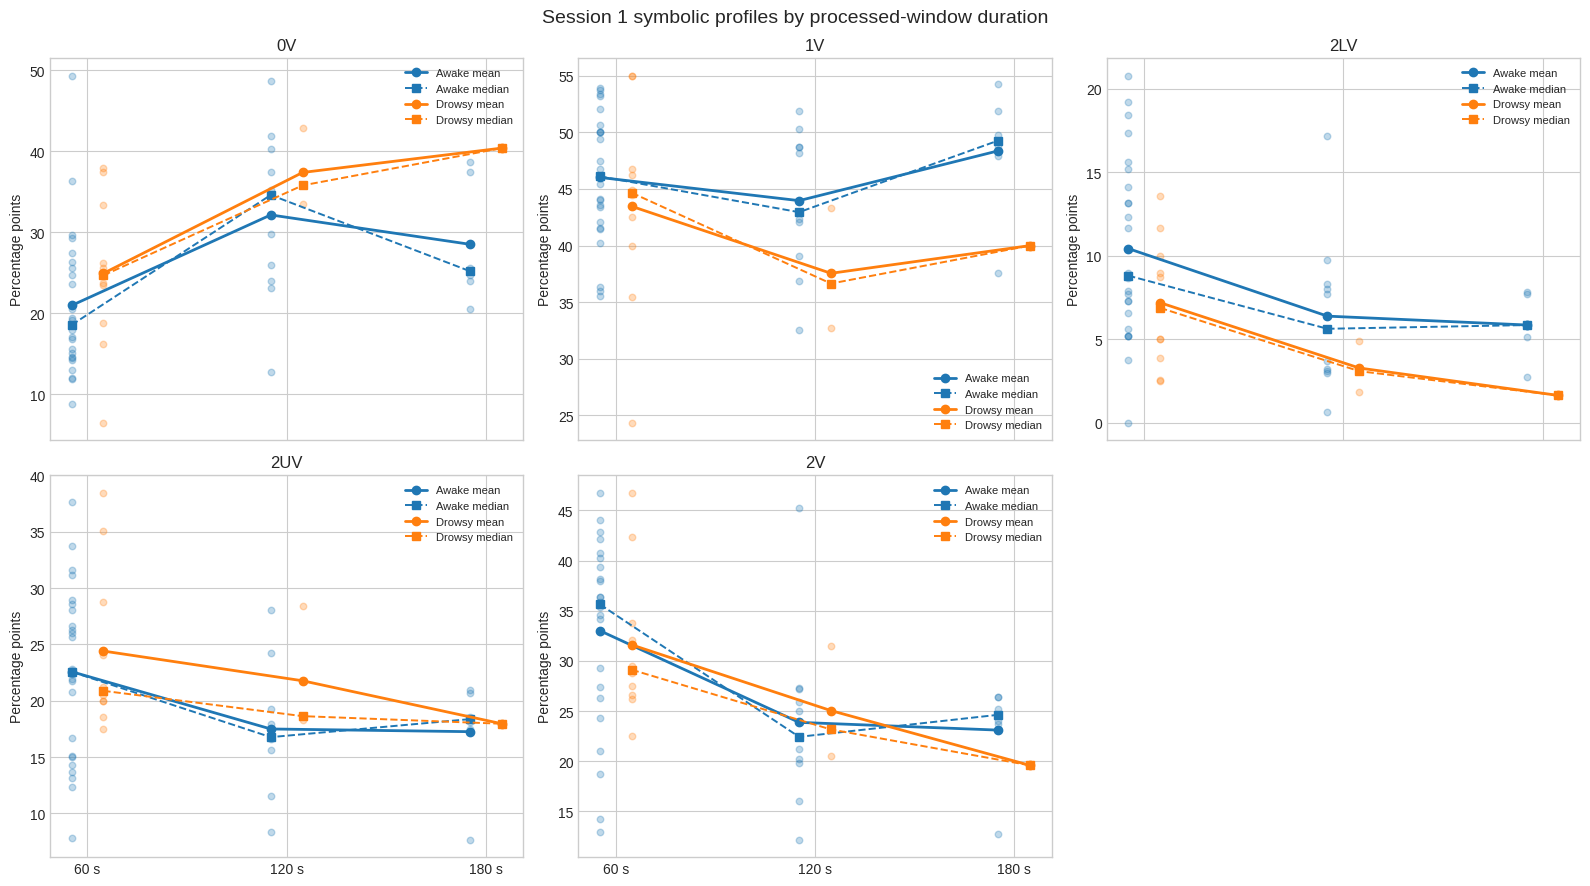

In [8]:
metric_labels = {
    "0V_pct": "0V",
    "1V_pct": "1V",
    "2LV_pct": "2LV",
    "2UV_pct": "2UV",
    "2V_pct": "2V",
}
state_colors = {"Awake": "tab:blue", "Drowsy": "tab:orange"}
x_positions = {60: 0, 120: 1, 180: 2}
state_offsets = {"Awake": -0.08, "Drowsy": 0.08}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes = axes.ravel()

for axis, metric in zip(axes, symbolic_metrics):
    for state in ("Awake", "Drowsy"):
        state_data = per_window_symbolic_table.query("State == @state")
        for size in WINDOW_SIZES:
            values = state_data.loc[
                state_data["window_size_s"] == size,
                metric,
            ].to_numpy()
            x = x_positions[size] + state_offsets[state]
            axis.scatter(
                np.full(values.size, x),
                values,
                color=state_colors[state],
                alpha=0.28,
                s=22,
            )

        group = (
            symbolic_group_summary_all
            .query("State == @state")
            .set_index("window_size_s")
            .loc[list(WINDOW_SIZES)]
        )
        xs = np.array([
            x_positions[size] + state_offsets[state]
            for size in WINDOW_SIZES
        ])
        axis.plot(
            xs,
            group[f"{metric}_mean"],
            color=state_colors[state],
            marker="o",
            linewidth=2,
            label=f"{state} mean",
        )
        axis.plot(
            xs,
            group[f"{metric}_median"],
            color=state_colors[state],
            marker="s",
            linestyle="--",
            linewidth=1.4,
            label=f"{state} median",
        )

    axis.set_title(metric_labels[metric])
    axis.set_ylabel("Percentage points")
    axis.set_xticks([0, 1, 2], labels=["60 s", "120 s", "180 s"])
    axis.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle(
    "Session 1 symbolic profiles by processed-window duration",
    fontsize=14,
)
fig.tight_layout()
plt.show()

In [9]:
contrast_rows = []
summary_indexed = symbolic_group_summary_all.set_index(
    ["window_size_s", "State"]
)

for size in WINDOW_SIZES:
    for metric in symbolic_metrics:
        awake_mean = float(
            summary_indexed.loc[(size, "Awake"), f"{metric}_mean"]
        )
        drowsy_mean = float(
            summary_indexed.loc[(size, "Drowsy"), f"{metric}_mean"]
        )
        awake_median = float(
            summary_indexed.loc[(size, "Awake"), f"{metric}_median"]
        )
        drowsy_median = float(
            summary_indexed.loc[(size, "Drowsy"), f"{metric}_median"]
        )
        contrast_rows.append({
            "window_size_s": size,
            "Metric": metric_labels[metric],
            "Delta_mean_Drowsy_minus_Awake": (
                drowsy_mean - awake_mean
            ),
            "Delta_median_Drowsy_minus_Awake": (
                drowsy_median - awake_median
            ),
        })

duration_contrast_table = pd.DataFrame(contrast_rows)
display(duration_contrast_table)

,window_size_s,Metric,Delta_mean_Drowsy_minus_Awake,Delta_median_Drowsy_minus_Awake
0,60,0V,3.968,6.132
1,60,1V,-2.555,-1.446
2,60,2LV,-3.242,-1.933
3,60,2UV,1.828,-1.695
4,60,2V,-1.413,-6.513
5,120,0V,5.244,1.187
6,120,1V,-6.416,-6.303
7,120,2LV,-3.106,-2.539
8,120,2UV,4.278,1.863
9,120,2V,1.172,0.735


## 7. Validation and descriptive conclusion

The report distinguishes complete-cohort findings from stationarity sensitivity and explicitly records the non-independence of overlapping windows.

In [10]:
all_invariants_pass = bool(
    per_window_symbolic_table["invariants_pass"].all()
)
all_ppi_valid = bool(
    (per_window_qc_table["n_invalid_ppi"] == 0).all()
)
enough_ppi = bool(
    (per_window_qc_table["n_ppi"] >= 50).all()
)
stationarity_fail_count = int(
    (~cohort_table["stationarity_pass_processed"]).sum()
)

mean_delta = duration_contrast_table.pivot(
    index="window_size_s",
    columns="Metric",
    values="Delta_mean_Drowsy_minus_Awake",
)

validation_report = pd.DataFrame([
    {
        "Finding": "Coverage",
        "Result": (
            "55 processed windows: 34 at 60 s, 14 at 120 s, "
            "7 at 180 s."
        ),
    },
    {
        "Finding": "Stationarity",
        "Result": (
            f"{stationarity_fail_count} windows fail processed "
            "stationarity; all are retained and flagged. A pass-only "
            "sensitivity summary is also reported."
        ),
    },
    {
        "Finding": "Peak/PPI QC",
        "Result": (
            "All windows have sufficient PPI and zero intervals "
            "outside 0.30–2.00 s."
        ),
    },
    {
        "Finding": "Symbolic invariants",
        "Result": "PASS independently for all 55 windows.",
    },
    {
        "Finding": "Consistent mean direction",
        "Result": (
            "Across 60/120/180 s, Drowsy mean 0V is higher, "
            "while mean 1V and 2LV are lower than Awake."
        ),
    },
    {
        "Finding": "2V pattern",
        "Result": (
            f"Drowsy−Awake mean 2V: "
            f"60 s {mean_delta.loc[60, '2V']:+.2f} pp, "
            f"120 s {mean_delta.loc[120, '2V']:+.2f} pp, "
            f"180 s {mean_delta.loc[180, '2V']:+.2f} pp; "
            "direction is not consistent."
        ),
    },
    {
        "Finding": "Interpretation limit",
        "Result": (
            "Windows overlap/nest, and Drowsy counts shrink from "
            "10 to 3 to 1 as duration increases. Trends are "
            "descriptive Session 1 observations only."
        ),
    },
])

experiment_pass = bool(
    all_invariants_pass and all_ppi_valid and enough_ppi
)
display(validation_report)
print(
    "SESSION 1 MULTI-DURATION STATUS:",
    "PASS" if experiment_pass else "REVIEW REQUIRED",
)

,Finding,Result
0,Coverage,"55 processed windows: 34 at 60 s, 14 at 120 s,..."
1,Stationarity,5 windows fail processed stationarity; all are...
2,Peak/PPI QC,All windows have sufficient PPI and zero inter...
3,Symbolic invariants,PASS independently for all 55 windows.
4,Consistent mean direction,"Across 60/120/180 s, Drowsy mean 0V is higher,..."
5,2V pattern,"Drowsy−Awake mean 2V: 60 s -1.41 pp, 120 s +1...."
6,Interpretation limit,"Windows overlap/nest, and Drowsy counts shrink..."


SESSION 1 MULTI-DURATION STATUS: PASS


# Báo cáo tổng hợp — Session 1 processed PPG (60/120/180 s)

## Phạm vi và trạng thái

- Phân tích **processed PPG only**, sampling rate xấp xỉ 50 Hz.
- Tổng cộng **55 windows**: 34 windows 60 s, 14 windows 120 s và 7 windows 180 s.
- Phân bố state: 60 s = 24 Awake/10 Drowsy; 120 s = 11 Awake/3 Drowsy; 180 s = 6 Awake/1 Drowsy.
- Có **5 windows fail processed-stationarity**, đều là Drowsy: 3 ở 60 s và 2 ở 120 s.
- Complete-cohort report giữ đủ 55 windows và gắn cờ stationarity; pass-only sensitivity report cũng được xuất phía trên.
- Trạng thái cuối: **SESSION 1 MULTI-DURATION STATUS: PASS**.

## Peak detection và PPI QC

Detector được giữ cố định: không smoothing thêm, minimum peak distance 0.30 s, prominence bằng 20% robust range P95−P5 của từng window.

- 55/55 windows có đủ PPI.
- **0 PPI** nằm ngoài khoảng pilot 0.30–2.00 s.
- Representative visual audit theo duration × state cho thấy marker gần systolic maxima, không có systematic double/missed detection trong các đoạn được kiểm tra.
- Có **115 abrupt-change records >20%** khi cộng trên mọi duration; do windows overlap/nest, đây không phải 115 biến cố độc lập.
- Cần lưu ý: 60-s W31 Drowsy có 24 transitions >20% (30.38%); 120-s W14 Drowsy, stationarity fail, có 32 (19.63%); 60-s W32 Drowsy, stationarity fail, có 8 (9.88%).

### PPI/HR group summary

Các ô có dạng **mean / median** giữa các windows.

| Duration | State | n | n PPI | Mean HR (bpm) | Mean PPI (ms) | PPI CV |
|---:|---|---:|---:|---:|---:|---:|
| 60 s | Awake | 24 | 79.79 / 79.00 | 81.51 / 81.02 | 740.70 / 745.82 | 0.068 / 0.066 |
| 60 s | Drowsy | 10 | 81.30 / 82.00 | 83.65 / 83.87 | 723.78 / 720.73 | 0.086 / 0.082 |
| 120 s | Awake | 11 | 161.09 / 159.00 | 81.73 / 80.65 | 738.89 / 750.51 | 0.075 / 0.079 |
| 120 s | Drowsy | 3 | 164.33 / 164.00 | 83.86 / 83.98 | 723.44 / 725.24 | 0.096 / 0.079 |
| 180 s | Awake | 6 | 242.50 / 241.50 | 81.73 / 81.30 | 738.88 / 741.98 | 0.076 / 0.076 |
| 180 s | Drowsy | 1 | 247.00 / 247.00 | 83.38 / 83.38 | 723.64 / 723.64 | 0.073 / 0.073 |

Drowsy có mean HR cao hơn và mean PPI thấp hơn Awake ở cả ba duration, nhưng đây chỉ là mô tả Session 1 trên các windows không độc lập.

## Frozen symbolic dynamics

- Core chạy trực tiếp trên uncorrected PPI.
- **55/55 windows pass** toàn bộ invariants:
  - 0V + 1V + 2LV + 2UV = 100%.
  - 2V = 2LV + 2UV.
  - n_words = n_intervals − 2.
  - Tất cả metrics finite.
- Bảng 55 dòng đầy đủ nằm tại output *Frozen symbolic dynamics — individual-window report*.

### Symbolic mean / median theo duration × state

Đơn vị là percentage points; mỗi ô có dạng **mean / median**.

| Duration | State | n | 0V | 1V | 2LV | 2UV | 2V |
|---:|---|---:|---:|---:|---:|---:|---:|
| 60 s | Awake | 24 | 20.97 / 18.56 | 46.02 / 46.10 | 10.43 / 8.81 | 22.58 / 22.58 | 33.01 / 35.63 |
| 60 s | Drowsy | 10 | 24.94 / 24.70 | 43.46 / 44.66 | 7.19 / 6.88 | 24.41 / 20.88 | 31.60 / 29.12 |
| 120 s | Awake | 11 | 32.16 / 34.62 | 43.97 / 42.95 | 6.38 / 5.62 | 17.50 / 16.77 | 23.88 / 22.44 |
| 120 s | Drowsy | 3 | 37.40 / 35.80 | 37.55 / 36.65 | 3.28 / 3.09 | 21.77 / 18.63 | 25.05 / 23.17 |
| 180 s | Awake | 6 | 28.53 / 25.21 | 48.37 / 49.27 | 5.85 / 5.85 | 17.25 / 18.37 | 23.11 / 24.63 |
| 180 s | Drowsy | 1 | 40.41 / 40.41 | 40.00 / 40.00 | 1.63 / 1.63 | 17.96 / 17.96 | 19.59 / 19.59 |

## Drowsy − Awake contrasts

### Difference of means

| Duration | Δ0V | Δ1V | Δ2LV | Δ2UV | Δ2V |
|---:|---:|---:|---:|---:|---:|
| 60 s | +3.97 | −2.56 | −3.24 | +1.83 | −1.41 |
| 120 s | +5.24 | −6.42 | −3.11 | +4.28 | +1.17 |
| 180 s | +11.88 | −8.37 | −4.22 | +0.70 | −3.51 |

### Difference of medians

| Duration | Δ0V | Δ1V | Δ2LV | Δ2UV | Δ2V |
|---:|---:|---:|---:|---:|---:|
| 60 s | +6.13 | −1.45 | −1.93 | −1.70 | −6.51 |
| 120 s | +1.19 | −6.30 | −2.54 | +1.86 | +0.74 |
| 180 s | +15.20 | −9.27 | −4.21 | −0.41 | −5.04 |

## Xu hướng mô tả

- **0V:** Drowsy cao hơn Awake theo cả mean và median ở 60/120/180 s.
- **1V:** Drowsy thấp hơn Awake theo cả mean và median ở cả ba duration.
- **2LV:** Drowsy thấp hơn Awake theo cả mean và median ở cả ba duration.
- **2UV:** mean cao hơn trong Drowsy nhưng median đổi hướng; chưa ổn định.
- **2V:** đổi hướng theo duration; không có pattern nhất quán.
- Chênh lệch 0V/1V có vẻ lớn hơn ở 180 s, nhưng Drowsy 180 s chỉ có một window nên không chứng minh duration effect.

## Stationarity sensitivity và giới hạn

| Duration | Awake pass | Drowsy pass |
|---:|---:|---:|
| 60 s | 24 | 7 |
| 120 s | 11 | 1 |
| 180 s | 6 | 1 |

- Lọc stationarity ảnh hưởng chủ yếu tới Drowsy; complete và pass-only summaries phải được đọc song song.
- Windows khác duration overlap/nest và không phải independent statistical units.
- Drowsy count giảm từ 10 → 3 → 1; không dùng các window như independent replicates.
- Kết quả hiện tại xác nhận pipeline và mô tả Session 1, không hỗ trợ causal autonomic/parasympathetic interpretation hoặc population inference.
